In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Leads.csv')

In [79]:
df.shape

(9240, 37)

In [80]:
df.tail()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [82]:
df.replace('Select', np.nan, inplace=True)

/tmp/ipython-input-1515912162.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_pct.index, y=null_pct.values, palette='viridis')


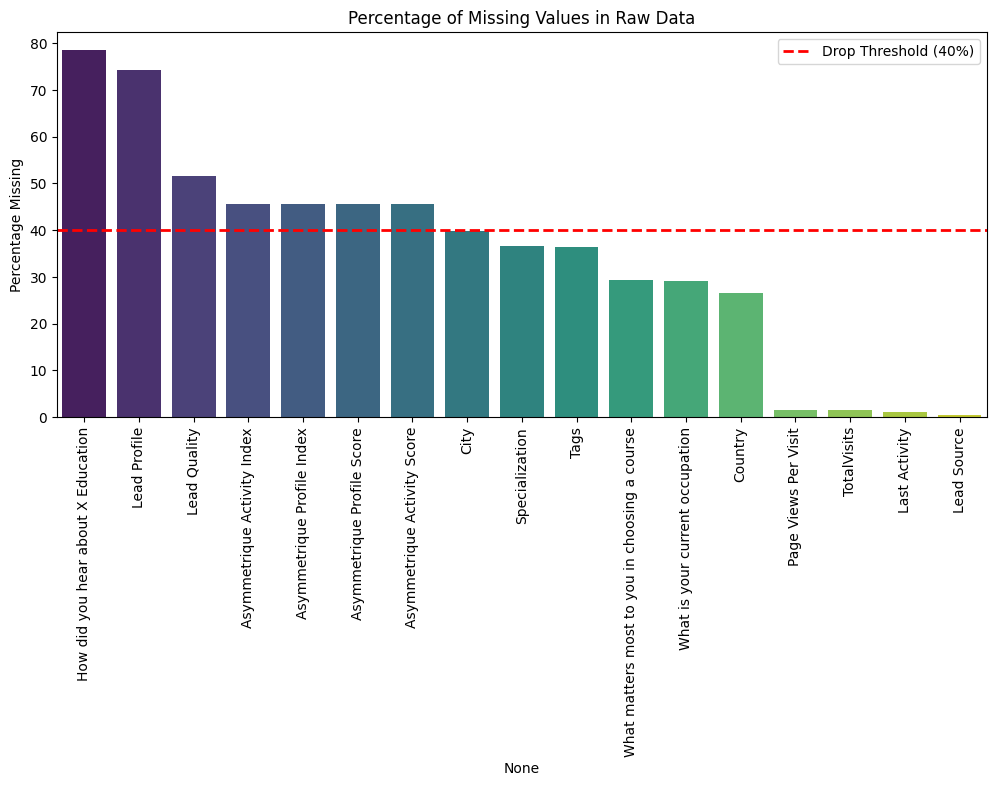

In [83]:
plt.figure(figsize=(12, 5))

# Calculate percentage of missing values
null_pct = df.isnull().mean() * 100

# Keep only columns with missing values
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

sns.barplot(x=null_pct.index, y=null_pct.values, palette='viridis')
plt.axhline(
    y=40,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Drop Threshold (40%)'
)

plt.title('Percentage of Missing Values in Raw Data')
plt.ylabel('Percentage Missing')
plt.xticks(rotation=90)
plt.legend()
plt.show()

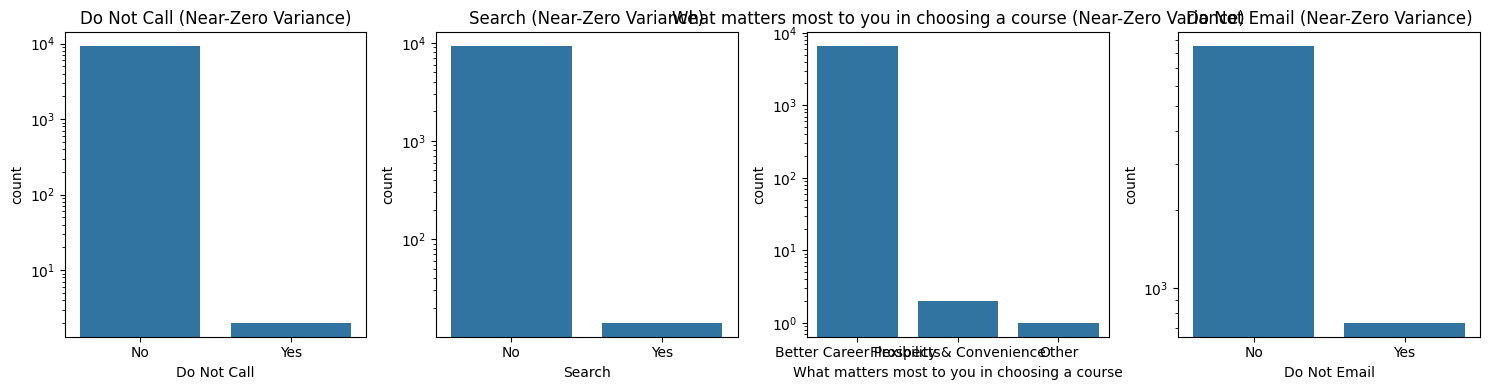

In [84]:
# 2. VISUALIZE ZERO-VARIANCE (LOW-INFORMATION) COLUMNS
# These columns have almost the same value for nearly all records
useless_cols = [
    'Do Not Call',
    'Search',
    'What matters most to you in choosing a course',
    'Do Not Email',
]

plt.figure(figsize=(15, 4))
for i, col in enumerate(useless_cols, 1):
    plt.subplot(1, 4, i)
    sns.countplot(x=col, data=df)
    plt.yscale('log')  # Log scale highlights very small counts
    plt.title(f'{col} (Near-Zero Variance)')

plt.tight_layout()
plt.show()




In [85]:


# 1. To find the Minimum value
minimum_value = df['TotalVisits'].min()
print("Minimum:", minimum_value)

# 2. To find the Maximum value
maximum_value = df['TotalVisits'].max()
print("Maximum:", maximum_value)

Minimum: 0.0
Maximum: 251.0


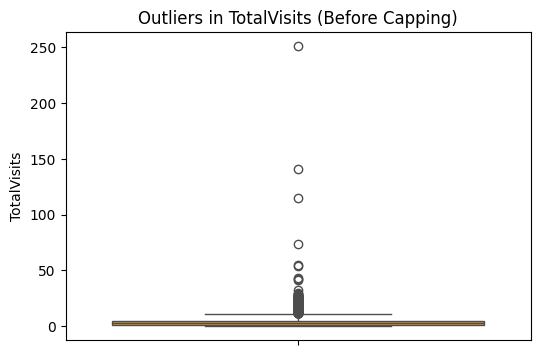

In [86]:
# Highlight unusually high visit counts
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['TotalVisits'], color='orange')
plt.title('Outliers in TotalVisits (Before Capping)')
plt.show()

In [87]:
limit = df['TotalVisits'].quantile(0.99)
limit

np.float64(17.0)

In [88]:
# --- CELL 3: CLEANING & IMPUTATION ---

# 1. DROP LOW-VALUE AND IDENTIFIER COLUMNS
cols_to_drop = [
    # High missing values (>40%)
    'Lead Quality', 'Lead Profile',
    'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'Asymmetrique Activity Score', 'Asymmetrique Profile Score',
    'How did you hear about X Education',


    # Near-zero variance (low information)
    'Magazine', 'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content', 'Get updates on DM Content',
    'I agree to pay the amount through cheque', 'X Education Forums',
    'Newspaper', 'Do Not Call', 'Newspaper Article', 'Digital Advertisement',
    'Through Recommendations', 'Search',
    'What matters most to you in choosing a course',
    'Do Not Email',

    # Identifier columns
    'Prospect ID', 'Lead Number'
]

print(f"Dropping {len(cols_to_drop)} columns...")
df_clean = df.drop(columns=cols_to_drop)

# 2. HANDLE MISSING VALUES (IMPUTATION)
# Categorical columns: use mode
# Numerical columns: use median
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 3. CAP OUTLIERS (WINSORIZATION)
# Cap 'TotalVisits' at the 99th percentile
limit = df_clean['TotalVisits'].quantile(0.99)
df_clean['TotalVisits'] = np.where(
    df_clean['TotalVisits'] > limit,
    limit,
    df_clean['TotalVisits']
)

print(f"Data cleaning completed. Final shape: {df_clean.shape}")


Dropping 23 columns...
Data cleaning completed. Final shape: (9240, 14)


/tmp/ipython-input-774589756.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
/tmp/ipython-input-774589756.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [89]:
df_clean.shape

(9240, 14)

In [90]:
conversion_map = {'No': 0, 'Yes': 1}

# 2. Apply the mapping to the column
df_clean['A free copy of Mastering The Interview'] = df_clean['A free copy of Mastering The Interview'].map(conversion_map)

In [91]:
from google.colab import files

print("Saving cleaned data...")

# 1. Save the file in the Colab environment
file_name = 'leads_cleaned.csv'
df_clean.to_csv(file_name, index=False)

print(f"File '{file_name}' saved successfully.")

# 2. Trigger download to the local machine
print("Starting file download...")
files.download(file_name)


Saving cleaned data...
File 'leads_cleaned.csv' saved successfully.
Starting file download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>